# Q4 Mixed Asset Class Portfolio Optimization Framework
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom portfolio optimizer framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework calculates the volatility and returns of a **multi-asset** portfolio with assets of equal weight, then proceeds to optimize the weights using the Markowitz and Black-Litterman models.

Objectives:
- Provide an evidence-based decision-making tool: Test your trading hypotheses with historical data.
- Allow strategy refinement: Identify strengths and weaknesses in your approach.
- Risk management: Understand potential returns and their respective volatility.
- Performance comparison: Benchmark the portfolio against two optimization methods.
- Flexibility: Custom-built framework allows for complete control over testing parameters.

This framework provides a solid foundation for quantitative trading strategy development and evaluation.

### This framework builds on Q3, but instead of using assets from the same sector, it implements multi-asset diversification. Therefore, most of the pipeline and procedures are very similar.
To prevent redundancies, the description will be kept short; see Q3 for further reference.


## 2. Data Pipeline

The structure of the data flow is as follows:

1. Data Management
    - Fetches and cleans real market data from Yahoo Finance
    - Handles historical price data for different stocks, crypto and ETFs, and bonds.
    - Stores processed data for efficient reuse  

2. Asset Checking and Signal Generation
    - Computing daily returns
    - Annualizing returns, volatility, and covariance matrix
    - Plotting correlation and covariance heatmaps 

3. Efficient Frontier - Markowitz model
    - Calculating the weighted returns and volatility
    - Computing the frontier curves for a range of returns
    - Monte Carlo simulation to generate 10,000 random portfolios 

4. Key portfolios
    - Equal weights portfolio: Baseline benchmark
    - Target return optimization: same return as equal weight, minimized volatility
    - Minimum variance portfolio: Leftmost point of frontier
    - Max. Sharpe portfolio: Unconstrained Sharpe maximization

5. Black-Litterman model
    - Market cap weights - equilibrium returns
    - View matrix P, view vector Q, confidence Ω
    - Posterior returns and calculation of μ_BL
    - Rerun optimization with μ_BL
    - Sensitivity test

6. Visualisation
    - Frontier plot with Monte Carlo coloured by Sharpe
        -  Individual assets
        -  Max. Sharpe
        -  MVP
        -  Capital Market Line
    - Portfolio value over 5 years, with key portfolios shown
    - Weight distribution from the different methods for all assets

This consolidated framework provides a complete pipeline from data acquisition through strategy testing to performance evaluation and visualization.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

import sys
sys.path.append('../utils')   # path relative to the notebook
from Q4_functions import returns_volatility, frontier_optimizer, max_sharpe, portfolio_return, portfolio_volatility, min_variance, portfolio_value
from common import fetch_portfolio_data, market_cap

## 3. Signal Generation

The historical data is downloaded by the function `fetch_portfolio_data()`.
The market cap for each asset is obtained by the function `market_cap()`.
The returns, volatility, and covariance are calculated by the function `returns_volatility()`.

In [2]:
# Load data
starting_capital = 10_000
period = 10
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=period)

tickersS = ['AAPL', 'NVDA', 'CVX', 'TSM']
tickersC = ['BTC-USD', 'ETH-USD']
tickersE = ['SPY', 'VEA', 'GLD', 'TLT']

dataS = fetch_portfolio_data(tickersS, start, end)
dataC = fetch_portfolio_data(tickersC, start, end)
dataE = fetch_portfolio_data(tickersE, start, end)

In [3]:
# checking data
print(dataS.shape)
print(dataS.isna().sum())
print(dataS.index.min(), dataS.index.max())
print()
print(dataC.shape)
print(dataC.isna().sum())
print(dataC.index.min(), dataC.index.max())
print()
print(dataE.shape)
print(dataE.isna().sum())
print(dataE.index.min(), dataE.index.max())
print()

# Combine with outer join, forward fill, then align to common start
dataALL = pd.concat([dataS, dataC, dataE], axis=1)
dataALL = dataALL.ffill()
dataALL = dataALL.dropna()  # drops pre-crypto period
dataALL = dataALL.sort_index()
print(dataALL.shape)
print(dataALL.index.min())

(2513, 4)
Ticker
AAPL    0
CVX     0
NVDA    0
TSM     0
dtype: int64
2016-03-10 00:00:00 2026-03-09 00:00:00

(3043, 2)
Ticker
BTC-USD    0
ETH-USD    0
dtype: int64
2017-11-09 00:00:00 2026-03-09 00:00:00

(2513, 4)
Ticker
GLD    0
SPY    0
TLT    0
VEA    0
dtype: int64
2016-03-10 00:00:00 2026-03-09 00:00:00

(3043, 10)
2017-11-09 00:00:00


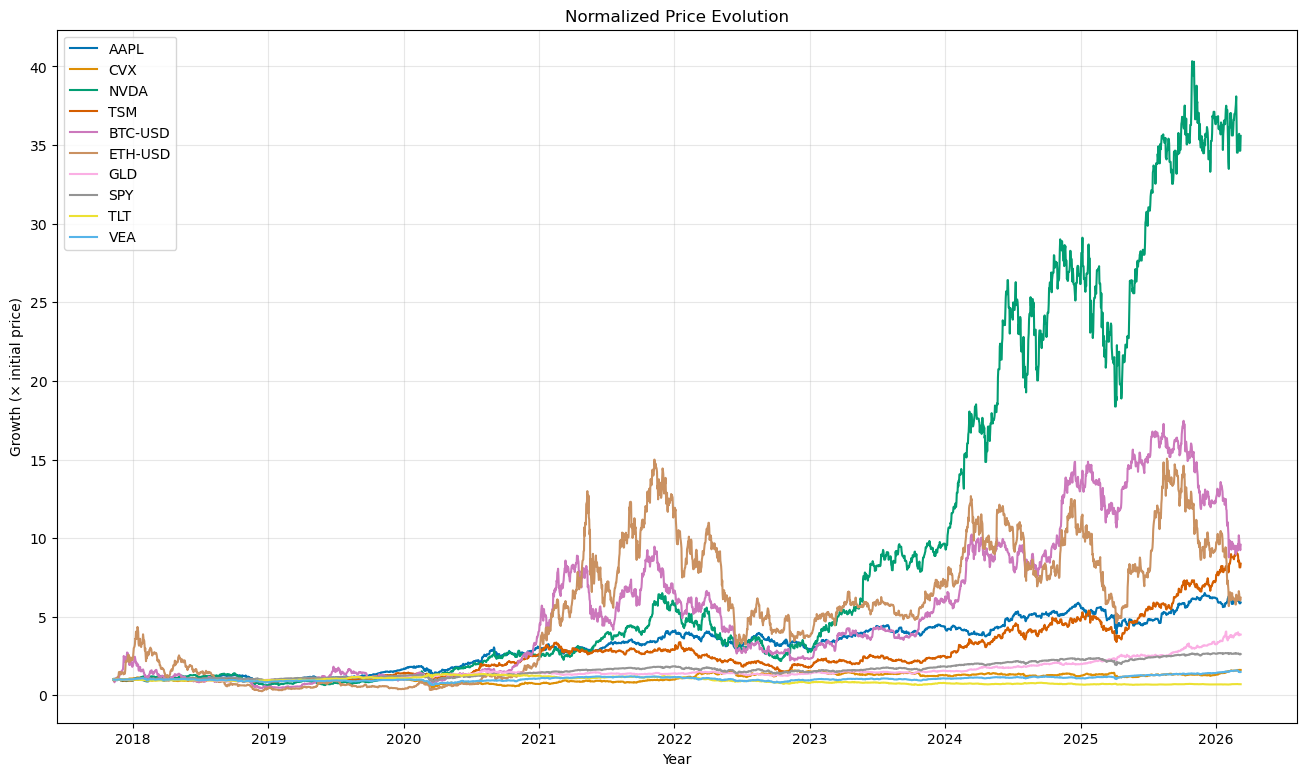

In [4]:
assets = dataALL.columns.tolist() #tickers sorted in alphabetical order, use this from now on

capsALL = market_cap(assets)

plt.figure(figsize=(16, 9))

colors = sns.color_palette("colorblind")

i = 0
for asset in assets:
    plt.plot(
        dataALL[asset] / dataALL[asset].iloc[0],   # normalize to 1
        label=asset,
        color=colors[i]
    )
    i+=1
            
plt.title('Normalized Price Evolution')
plt.xlabel('Year')
plt.ylabel('Growth (× initial price)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

,Annualized_Return,Annualized_Volatility
Ticker,,
AAPL,0.196167,0.253083
CVX,0.075857,0.257289
NVDA,0.468679,0.421416
TSM,0.246495,0.298267
BTC-USD,0.408236,0.555276
ETH-USD,0.504599,0.713758
GLD,0.128707,0.133856
SPY,0.097208,0.159519
TLT,-0.020056,0.129078


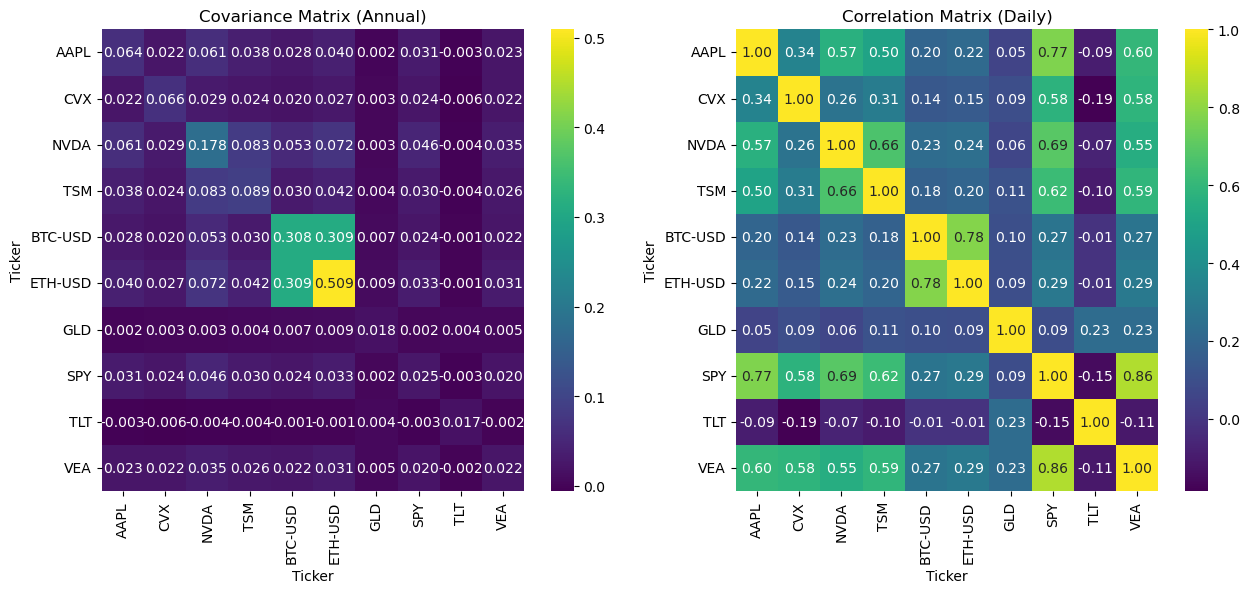

In [5]:
mu_annual, sigma_annual, cov_annual = returns_volatility(dataALL)

## 4. Efficient Frontier - Markowitz Model

The frontier values are calculated by the function `frontier_optimizer()`.  
Once the frontier is defined, thousands of random portfolios are calculated using the Monte Carlo simulation method.

In [6]:
return_min = mu_annual.min()  # lowest individual asset return
return_max = mu_annual.max()  # highest individual asset return
target_returns = np.linspace(return_min, return_max, 100)
frontier_volatilities, frontier_returns, frontier_weights = frontier_optimizer(mu_annual, sigma_annual, cov_annual, target_returns)

In [7]:
n_simulations = 10_000
sim_returns, sim_vols, sim_sharpes = [], [], []

for _ in range(n_simulations):
    w = np.random.dirichlet(np.ones(len(assets)))
    r = portfolio_return(w, mu_annual)
    v = portfolio_volatility(w, cov_annual)
    s = (r - 0.04) / v
    sim_returns.append(r)
    sim_vols.append(v)
    sim_sharpes.append(s)

## 5. Key Portfolios

After the frontier and random portfolios are calculated, we proceed to calculate the key portfolios for comparison.
   - The first is the portfolio with equally distributed weight. This will serve as a benchmark, as it has not been optimized.
   - The second optimizes the target return, aiming to minimize volatility but to obtain the same returns as the benchmark.
   - The third finds the portfolio with the absolute minimum volatility, the leftmost point on the frontier curve.
   - The fourth optimizes the Sharpe ratio without any constraints.

In [8]:
# Equal-weight portfolio

w_equal = np.ones(len(assets)) / len(assets)

# Equal weight portfolio stats
w_equal = np.ones(len(assets)) / len(assets)
ret_equal = portfolio_return(w_equal, mu_annual)
vol_equal = portfolio_volatility(w_equal, cov_annual)
sharpe_equal = (ret_equal - 0.04) / vol_equal

# display(pd.Series(w_equal, index=assets).round(4))

port_value_eq = portfolio_value(starting_capital, dataALL, w_equal)

In [9]:
# Optimizing the portfolio weight to obtain the same returns as the equally distributed weights but minimizing the volatility

# Now find the frontier portfolio at the same return
result = min_variance(ret_equal, mu_annual, cov_annual)
w_optimized = result.x
vol_optimized = portfolio_volatility(w_optimized, cov_annual)

print(f"Equal weight: ret={ret_equal:.3f}, vol={vol_equal:.3f}, sharpe={sharpe_equal:.3f}")
print(f"Optimized:    ret={ret_equal:.3f}, vol={vol_optimized:.3f}")
print(f"Volatility reduction: {(vol_optimized/vol_equal - 1)*100:.1f}%")

# display(pd.Series(w_optimized, index=assets).round(4))

port_value_op = portfolio_value(starting_capital, dataALL, w_optimized)

Equal weight: ret=0.215, vol=0.195, sharpe=0.896
Optimized:    ret=0.215, vol=0.144
Volatility reduction: -26.2%


In [10]:
# calculating the case with the minimum volatility from the efficient frontier

idx = np.argmin(frontier_volatilities)
min_vol = frontier_volatilities[idx]
min_ret = frontier_returns[idx]
min_w = frontier_weights[idx]


print(f"Returns: {min_ret:.4f}")
print(f"Min. Volatility: {min_vol:.4f}")


# display(pd.Series(min_w, index=assets).round(4))

port_value_mi = portfolio_value(starting_capital, dataALL, min_w)

Returns: 0.0541
Min. Volatility: 0.0838


In [11]:
# calculating the weights for maximum Sharpe value
    
sharpe_result = max_sharpe(mu_annual, cov_annual)
sharpe_weights = sharpe_result.x
sharpe_ret = portfolio_return(sharpe_weights, mu_annual)
sharpe_vol = portfolio_volatility(sharpe_weights, cov_annual)


print(f"Sharpe Returns: {sharpe_ret:.4f}")
print(f"Sharpe Volatility: {sharpe_vol:.4f}")
print(f"Sharpe Ratio: {sharpe_result.fun:.4f}")


# display(pd.Series(sharpe_weights, index=assets).round(4))

port_value_sh = portfolio_value(starting_capital, dataALL, sharpe_weights)

Sharpe Returns: 0.2619
Sharpe Volatility: 0.1774
Sharpe Ratio: -1.2503


## 6. Black-Litterman Model

After finishing the previous calculation and seeing some limitations of the Markowitz model, we ran a few extra calculations.
    - The current market cap values are used to calculate weights for each of the assets.
    - Outperformers and underperformers are selected, as well as an outerperformance percentage.
    - Posterior returns are calculated, and the optimization is rerun with the new values.
    - Sensitivity test

In [18]:
# Step 1 - Market cap weights
w_market = capsALL["MarketCap"]/capsALL["MarketCap"].sum()

# display(pd.Series(w_market.values, index=assets).round(4))

# Step 2 - Equilibrium returns
lam = 2.5
pi = lam * cov_annual @ w_market

# Step 3 - Black-Litterman posterior
tau = 0.05

# Outperformers get +1/4, underperformers get -1/3
# (normalized so each side sums to 1)
P = np.array([[1/3, 0,  1/3, 0,  1/3, -1, 0,  0,  0,  0]])
#             AAPL  CVX NVDA TSM BTC  ETH GLD SPY TLT VEA

Q = np.array([0.05]) # 10% outperformance
omega = tau * P @ cov_annual @ P.T  # proportional to variance of views

# second run
# omega = np.diag([0.001])  # high confidence, small uncertainty
# Q = np.array([0.10])  # you believe 10% outperformance

# Posterior returns
M1 = np.linalg.inv(tau * cov_annual)
M2 = P.T @ np.linalg.inv(omega) @ P
M3 = M1 @ pi + P.T @ np.linalg.inv(omega) @ Q
mu_bl = np.linalg.solve(M1 + M2, M3)

display(pd.DataFrame({"Ticker": pi.index, "pi": pi.values, "mu_bl": mu_bl}))

,Ticker,pi,mu_bl
0,AAPL,0.126425,0.127880
1,CVX,0.063882,0.063372
2,NVDA,0.249468,0.252714
3,TSM,0.145109,0.146221
4,BTC-USD,0.178196,0.154698
5,ETH-USD,0.218989,0.170577
6,GLD,0.009263,0.008641
7,SPY,0.085778,0.085869
8,TLT,-0.007805,-0.007999
9,VEA,0.067573,0.066976


In [19]:
# BL optimization

# Market weights
ret_market = portfolio_return(w_market, mu_bl)
vol_market = portfolio_volatility(w_market, cov_annual)
sharpe_market = (ret_market - 0.04) / vol_market


# Now find the frontier portfolio at the same return
result = min_variance(ret_market, mu_bl, cov_annual)
w_optimized_BL = result.x
vol_optimized_BL = portfolio_volatility(w_optimized_BL, cov_annual)

print(f"Market weight: ret={ret_market:.3f}, vol={vol_market:.3f}, sharpe={sharpe_market:.3f}")
print(f"Optimized:     ret={ret_market:.3f}, vol={vol_optimized_BL:.3f}")
print(f"Volatility reduction: {(vol_optimized_BL/vol_market - 1)*100:.1f}%")

display(pd.Series(w_optimized_BL, index=assets).round(4))

port_value_bl = portfolio_value(starting_capital, dataALL, w_market)

Market weight: ret=0.170, vol=0.262, sharpe=0.495
Optimized:     ret=0.170, vol=0.261
Volatility reduction: -0.5%


AAPL       0.3032
CVX        0.0281
NVDA       0.3505
TSM        0.1390
BTC-USD    0.0930
ETH-USD    0.0000
GLD        0.0128
SPY        0.0637
TLT        0.0052
VEA        0.0047
dtype: float64

## 7. Visualisation
Three main plots are shown summarizing our findings:
   1. Frontier plot with Monte Carlo coloured by Sharpe.
   2. Portfolio value over 5 years.
   3. Weight distribution for all assets.

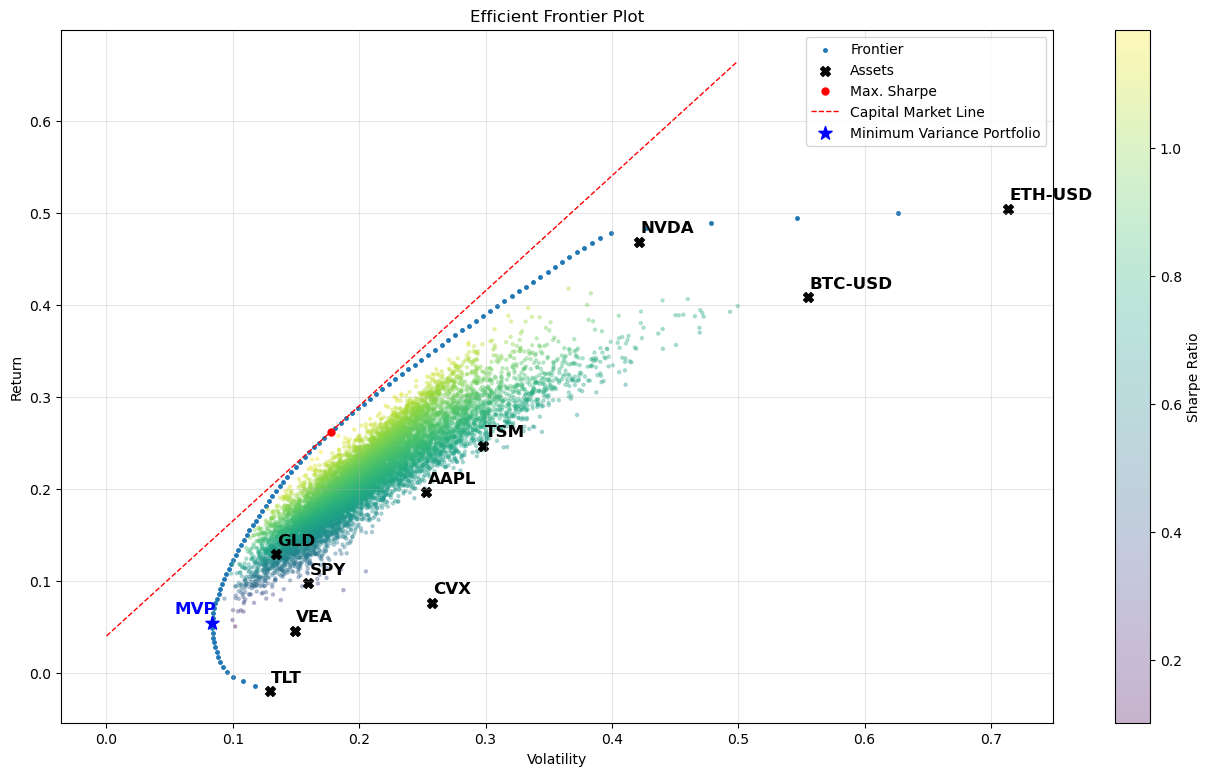

In [14]:
plt.figure(figsize=(16, 9))
colors = sns.color_palette("colorblind")

plt.scatter(frontier_volatilities, frontier_returns, s=25, marker='.', label='Frontier')

plt.scatter(sim_vols, sim_returns, c=sim_sharpes, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(label='Sharpe Ratio')

plt.scatter(sigma_annual, mu_annual, s=50, c='k', marker='X', label='Assets')
for asset in assets:
    plt.annotate(asset, (sigma_annual[asset]+0.001, mu_annual[asset]+0.01),fontweight='bold',fontsize=12)

plt.scatter(sharpe_vol, sharpe_ret, s=25, c='r', marker='o', label='Max. Sharpe')

# CML: from (0, rf) through (sharpe_vol, sharpe_ret)
cml_x = np.linspace(0, max(sim_vols), 100)
cml_y = 0.04 + (sharpe_ret - 0.04) / sharpe_vol * cml_x
plt.plot(cml_x, cml_y, 'r--', linewidth=1, label='Capital Market Line')

plt.scatter(min_vol, min_ret, s=100, c='b', marker='*', label='Minimum Variance Portfolio')
plt.annotate('MVP', (min_vol-0.03, min_ret+0.01),fontweight='bold',fontsize=12, color='b')

plt.grid(True, alpha=0.3)
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.legend()

plt.title('Efficient Frontier Plot')
plt.show()

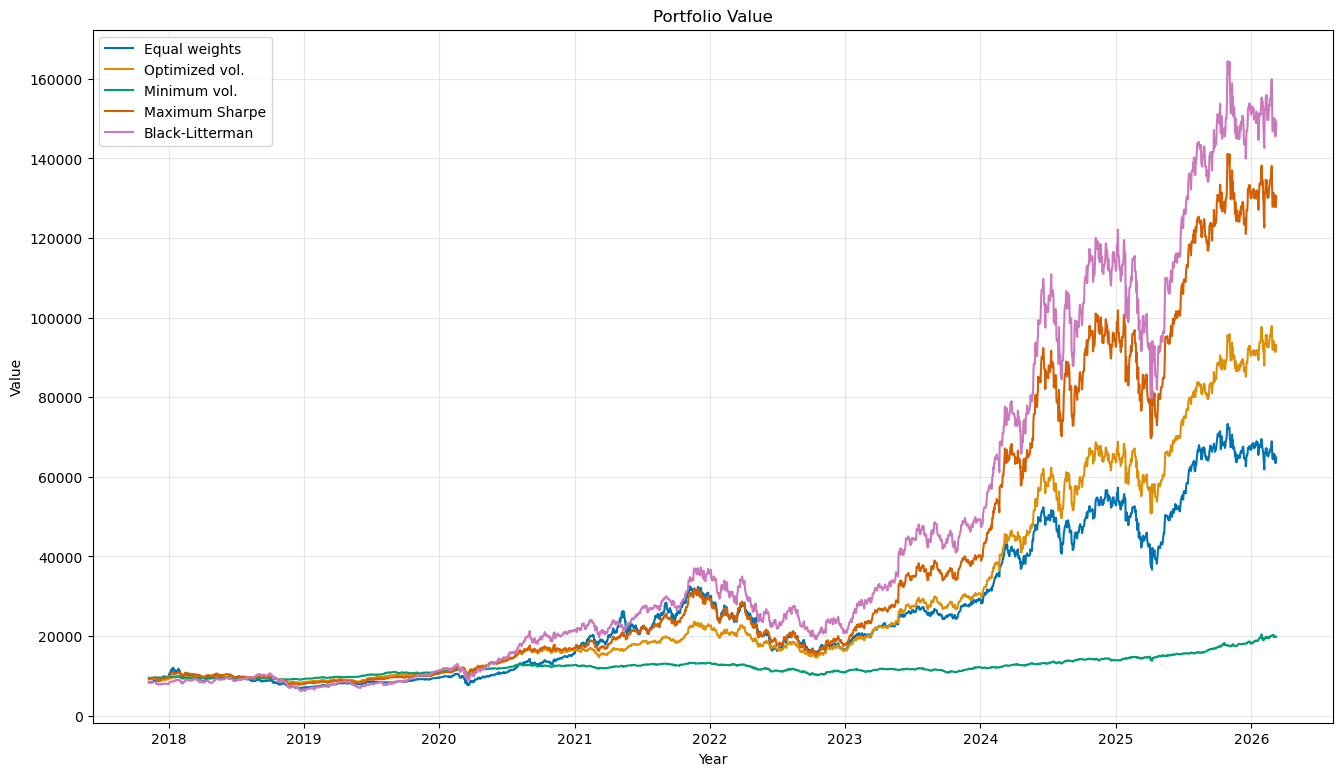

In [15]:
plt.figure(figsize=(16, 9))

colors = sns.color_palette("colorblind")

plt.plot(port_value_eq, color=colors[0], label='Equal weights')
plt.plot(port_value_op, color=colors[1], label='Optimized vol.')
plt.plot(port_value_mi, color=colors[2], label='Minimum vol.')
plt.plot(port_value_sh, color=colors[3], label='Maximum Sharpe')
plt.plot(port_value_bl, color=colors[4], label='Black-Litterman')

plt.title('Portfolio Value')
plt.xlabel('Year')
plt.ylabel('Value')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

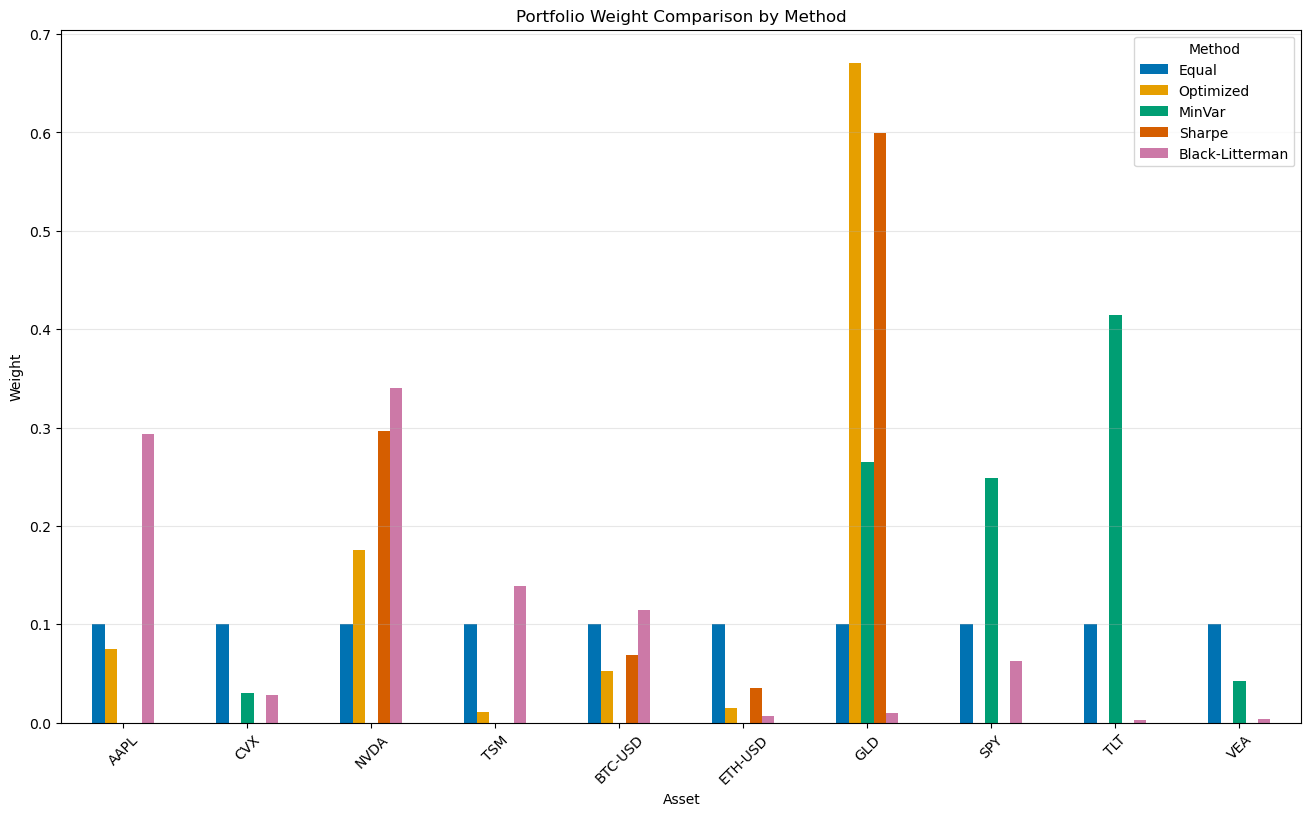

In [16]:
weights_df = pd.DataFrame({
    "Equal": w_equal,
    "Optimized": w_optimized,
    "MinVar": min_w,
    "Sharpe": sharpe_weights,
    "Black-Litterman": w_optimized_BL,
    },
    index=assets
)

colors = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#F0E442", "#56B4E9", "#000000"
]

weights_df.plot(kind="bar", figsize=(16, 9), color=colors[:len(weights_df.columns)])

plt.title("Portfolio Weight Comparison by Method")
plt.ylabel("Weight")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Method")

plt.show()

## 8. Conclusions

For this particular scenario, in which we look back at ~8-year data from hand-picked stocks, cryptocurrencies, and ETFs/Bonds to achieve asset class diversification, as opposed to Q3, which focused on the *"Magnificent 7"*.

For this portfolio, the following assets have been selected:
   1. Stocks: Apple, Nvidia, Chevron, Taiwan Semiconductor
   2. Cryptocurrencies: Bitcoin, Ethereum
   3. ETFs/Bonds: S&P500 index, Gold, Treasury bond, Developed Markets

These 10 assets have equally distributed weights (10% each) as a starting point and have been optimised with different methods. We can draw the following conclusions:

- **Zero correlation means independence, not opposition.** TLT/BTC at -0.01 means Treasury bonds and crypto operate in completely separate behavioural universes during normal periods. That's as valuable as negative correlation for diversification — the portfolio is exposed to two entirely uncorrelated sources of risk and return simultaneously.

- **Sector diversification and asset class diversification are fundamentally different.** Reshuffling Mag 7 weights moved MVP volatility from 0.24 to 0.22 at best. Adding TLT and GLD moved it to 0.07 — a 3.4x improvement. The source of diversification matters more than the number of assets. Genuine variance reduction requires genuinely uncorrelated asset classes, not more stocks from the same sector.

- **The optimizer is ruthless about redundancy.** CVX and VEA — both relatively stable assets — were consistently zeroed out because their high correlation with SPY made them redundant. Stability alone does not earn portfolio weight; *uncorrelated* stability does. This is the efficiency principle applied across asset classes.

- **Bonds protect against recession but fail during inflation.** TLT dominated the minimum variance portfolio at 41.5% — its negative correlation with equities makes it the strongest crisis hedge in the universe. However, the 2022 rate hiking cycle crushed TLT while equities also fell simultaneously. Bonds protect against equity crashes driven by recession fear, but fail catastrophically when the risk is inflation. No asset is an unconditional safe haven.

- **Gold is the optimizer's preferred diversifier in this universe.** GLD dominated the target-return optimised (67%) and maximum Sharpe (60%) portfolios due to its near-zero correlation with all equity assets (0.05–0.11). It delivers low but steady returns with no dramatic crashes — not exciting, genuinely defensive. Combined with NVDA's high return, the max Sharpe portfolio essentially holds NVDA for return and GLD as ballast.

- **Cross-asset diversification dramatically shifts the efficient frontier.** The MVP volatility dropped from 0.24 (Q3, Mag 7) to 0.07 (Q4, mixed assets) — not because of better stock selection, but because TLT and GLD introduced negative or near-zero correlations that no combination of tech stocks can replicate.

- **Black-Litterman is structurally misaligned with mixed asset class universes.** After correcting a bug in the original implementation, the BL model achieved only ~0.5% volatility reduction — not the 44.9% previously reported. The root cause is architectural: BL's equilibrium prior derives expected returns from market cap weights, which systematically suppresses GLD and TLT. Gold and Treasury bonds have relatively small market caps compared to NVDA or AAPL, so the equilibrium framework assigns them near-zero or negative expected returns regardless of investor views. The model was designed for equity portfolios where market cap is a meaningful signal. In a mixed asset universe, asset-class-specific priors would be required — a known limitation of standard BL implementations. The corrected BL weights (NVDA 36%, AAPL 32%, BTC 11%) reflect the investor view correctly but sacrifice the variance reduction that GLD and TLT would otherwise provide.

- **Weights are derived from and evaluated on the same historical period.** The portfolio value comparison is illustrative of framework behaviour, not a prediction of future performance. A proper evaluation requires rolling window optimisation with out-of-sample testing.

## 9. Limitations & Next Steps

The three most important limitations of this model are the following:  
   - Calendar misalignment — crypto trades 24/7 while stocks trade 5 days per week. Forward filling stock prices on weekends understates their true volatility relative to crypto and artificially reduces their covariance with crypto assets. Weekly returns aggregation is the cleaner solution.
   - In-sample optimization — weights are derived from and evaluated on the same historical period. The dramatic results (10k → 145k for BL) reflect historical performance, not future prediction. A proper evaluation requires rolling window optimization with out-of-sample testing.
   - Static weights with no rebalancing — optimal weights are calculated once and held fixed. As asset prices move, actual weights drift from optimal. A portfolio starting at 36% NVDA will quickly become 60%+ NVDA if NVDA continues rallying, fundamentally changing the risk profile. Periodic rebalancing is required in practice — but rebalancing has transaction costs that erode returns.

Some interesting next steps to go deeper on this project would be:
- Implement weekly returns instead of forward filling or removing data from the assets.
- Add rebalancing costs — frequent rebalancing erodes returns
- Implementing a tracking error constraint to optimize weights but penalize large deviations from current holdings. In order to get improvement without excessive turnover.

Just to name a few.